In [87]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [88]:
def algorithm(foot_data_array):
    steps_stance_dict = {}
    steps_swing_dict = {}

    #keeps track of steps taken with a counter
    current_step_stance = []
    current_step_swing = []
    step_stance_counter = 1
    step_swing_counter = 1

    for index in range(len(foot_data_array)):
        if (sum(foot_data_array[index, :])) == foot_data_array[index, 0]: # Swing Phase, leg in air
            #updates stance phase counter
            if len(current_step_stance) > 0:
                steps_stance_dict[f"stance_step{step_stance_counter}"] = np.array(current_step_stance)
                step_stance_counter += 1
                current_step_stance = []

            #appends data into swing array
            current_step_swing.append(foot_data_array[index, :])

        elif (sum(foot_data_array[index, :])) != foot_data_array[index, 0]: #Stance Phase
            #updates swing phase counter
            if len(current_step_swing) > 0:
                steps_swing_dict[f"swing_step{step_swing_counter}"] = np.array(current_step_swing)
                step_swing_counter += 1
                current_step_swing = []

            #appends data into stance array
            current_step_stance.append(foot_data_array[index, :])

        else:
            print("error")

    #gives each step a name and puts swing & stance into separate dictionaries
    if len(current_step_swing) > 0: #in stance pahse
        steps_swing_dict[f"swing_step{step_swing_counter}"] = np.array(current_step_swing)
    else: #in swing phase
        steps_stance_dict[f"stance_step{step_stance_counter}"] = np.array(current_step_stance)

    #print num of steps
    #num_stance_steps = len(steps_stance_dict)
    #num_swing_steps = len(steps_swing_dict)
    #print(f"Total stance steps: {num_stance_steps}")
    #print(f"Total swing steps: {num_swing_steps}")

    for value in steps_stance_dict.values():
        value[:,0]=value[:,0]-value[0,0]

    #print(steps_stance_dict)
    return steps_stance_dict

In [89]:
def filter_stance_steps(steps_stance_dict, z_threshold_standing=0.2, z_threshold_short=2.9):
    """
    Applies two-pass Z-score filtering to remove standing steps (too long)
    and glitch steps (too short) from the stance dictionary.
    """
    if not steps_stance_dict:
        return {}

    #extract row counts for all detected stance steps
    row_counts = np.array([step_array.shape[0] for step_array in steps_stance_dict.values()])

    #detect and eliminate standing outliers (too long)
    mean_rows = np.mean(row_counts)
    std_rows = np.std(row_counts)
    outlier_threshold_standing_z = mean_rows + (z_threshold_standing * std_rows)

    #filters standing steps to calculate accurate baseline stats for walking
    no_stand_walking_counts = row_counts[row_counts <= outlier_threshold_standing_z]

    if len(no_stand_walking_counts) == 0:
        return {}

    #detects short outliers (glitches/noise) using walking baseline
    no_stand_mean = np.mean(no_stand_walking_counts)
    no_stand_std = np.std(no_stand_walking_counts)
    short_threshold = no_stand_mean - (z_threshold_short * no_stand_std)

    #filters stance dictionary to keep only standard walking steps
    filtered_stance_dict = {
        step_name: step_array
        for step_name, step_array in steps_stance_dict.items()
        if short_threshold <= step_array.shape[0] <= outlier_threshold_standing_z
    }

    # standing_still_z = {
    #     step_name: step_array.shape[0]
    #     for step_name, step_array in steps_stance_dict.items()
    #     if step_array.shape[0] > outlier_threshold_standing_z
    # }
    # print(f"stand outlier threshold > {z_threshold_standing}")
    # print(f"got {len(standing_still_z)} standing 'steps':")
    # for name, duration in standing_still_z.items():
    #     print(f"  {name}: {duration} rows")

    # true_short_steps = {
    #     step_name: step_array.shape[0]
    #     for step_name, step_array in steps_stance_dict.items()
    #     if step_array.shape[0] < short_threshold
    # }
    # print(f"short outlier threshold: < {short_threshold:.1f} rows")
    # print(f"got {len(true_short_steps)} short steps:")
    # for name, duration in true_short_steps.items():
    #     print(f"  {name}: {duration} rows")

    # print(f"Original stance steps: {len(steps_stance_dict)}")
    # print(f"Filtered stance steps: {len(filtered_stance_dict)}")

    return filtered_stance_dict

In [90]:
#making a list of LOGS 7, 11, 12, 13, 14
log_list = ["LOG7", "LOG11", "LOG12", "LOG13", "LOG14"]
dfs = {}
foot_data = {}
foot_data_array = {}
raw_stance_dict = {}
filtered_stance_dict = {}

for log in log_list:
    dfs[f"df{log}"] = pd.read_csv(f"{log}.CSV")
    foot_data[f"{log}"] = dfs[f"df{log}"][['Time_ms', '5th_Metatarsal',
                '4th_Metatarsal',
                '1st_Metatarsal',
                'Heel', 'Medial_Arch',
                'Lateral_Arch']]
    foot_data_array[f"{log}"] = foot_data[f"{log}"].to_numpy()
    raw_stance_dict[f"{log}"] = algorithm(foot_data_array[f"{log}"])
    filtered_stance_dict[f"{log}"] = filter_stance_steps(raw_stance_dict[f"{log}"])

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [92]:
#V4
bounded_feature_matrix = []
true_labels = []

np.random.seed(42)

for log_name, stance_dict in filtered_stance_dict.items():
    step_items = list(stance_dict.items())

    # Subsample LOG7 to match class sizes (~40 steps)
    if log_name == "LOG7" and len(step_items) > 40:
        indices = np.random.choice(len(step_items), size=40, replace=False)
        step_items = [step_items[i] for i in indices]

    for step_name, step_array in step_items:
        # 1. Exact Temporal Characteristic in Milliseconds
        start_time = step_array[0, 0]
        end_time = step_array[-1, 0]
        duration_ms = end_time - start_time

        # 2. Extract Sensor Pressure Channels (Columns 1 through 6)
        pressures = step_array[:, 1:]

        # Explicit sensor indices
        IDX_5TH_MET = 0
        IDX_4TH_MET = 1
        IDX_1ST_MET = 2
        IDX_HEEL    = 3
        IDX_MED_ARC = 4
        IDX_LAT_ARC = 5

        # Regional Pressure Sums
        heel_sum = np.sum(pressures[:, IDX_HEEL])
        forefoot_sum = np.sum(pressures[:, [IDX_1ST_MET, IDX_4TH_MET, IDX_5TH_MET]])
        medial_sum = np.sum(pressures[:, [IDX_1ST_MET, IDX_MED_ARC]])
        lateral_sum = np.sum(pressures[:, [IDX_5TH_MET, IDX_LAT_ARC]])
        total_pressure = np.sum(pressures) + 1e-6

        # Bounded Differential Indices (-1.0 to +1.0)
        eps = 1e-6
        medial_index = (medial_sum - lateral_sum) / (medial_sum + lateral_sum + eps)
        heel_index = (heel_sum - forefoot_sum) / (heel_sum + forefoot_sum + eps)

        # Relative Force Ratios
        heel_pct = heel_sum / total_pressure
        forefoot_pct = forefoot_sum / total_pressure

        bounded_feature_matrix.append([
            duration_ms,
            medial_index,
            heel_index,
            heel_pct,
            forefoot_pct
        ])
        true_labels.append(log_name)

X_bounded = np.array(bounded_feature_matrix)
y = np.array(true_labels)

# Check average values per log to confirm clean scaling
df_clean = pd.DataFrame(X_bounded, columns=['duration', 'medial_index', 'heel_index', 'heel_pct', 'forefoot_pct'])
df_clean['log'] = y
print("--- Clean Bounded Averages ---")
print(df_clean.groupby('log').mean())

# Scale features safely without outlier distortion
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bounded)

# Run K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(X_scaled)

results_df = pd.DataFrame({'True_Log': y, 'Cluster_ID': predicted_clusters})

gait_cluster_names = {
    0: "STANDARD",
    1: "HEELWALK",
    2: "LIMP",
    3: "TIPTOE",
    4: "DUCKWALK"
}
results_df['Cluster_Name'] = results_df['Cluster_ID'].map(gait_cluster_names)
print("\n--- Bounded Explicit Feature Matrix Separation ---")
#print(pd.crosstab(results_df['True_Log'], results_df['Cluster_ID']))
print(pd.crosstab(results_df['True_Log'], results_df['Cluster_Name']))

--- Clean Bounded Averages ---
         duration  medial_index  heel_index  heel_pct  forefoot_pct
log                                                                
LOG11  403.315789      0.236485   -0.302513  0.335130      0.626020
LOG12  473.480000     -0.768161   -0.512187  0.221856      0.682901
LOG13  471.729730      0.000000    1.000000  1.000000      0.000000
LOG14  567.270270      0.275132   -1.000000  0.000000      0.999961
LOG7   610.250000     -0.663850   -0.314353  0.278107      0.537130

--- Bounded Explicit Feature Matrix Separation ---
Cluster_Name  DUCKWALK  HEELWALK  LIMP  STANDARD  TIPTOE
True_Log                                                
LOG11                0         2    36         0       0
LOG12               21         0     2         2       0
LOG13                0        37     0         0       0
LOG14                0         0     0         0      37
LOG7                 0         1     0        39       0


In [93]:
# Verify if Medial/Lateral Ratios actually differ across logs
df_features = pd.DataFrame(X_bounded, columns=['duration', 'medial_lateral_ratio', 'heel_forefoot_ratio', 'heel_sum', 'forefoot_sum'])
df_features['log'] = y

print("--- Average Feature Values per Log ---")
print(df_features.groupby('log').mean())

--- Average Feature Values per Log ---
         duration  medial_lateral_ratio  heel_forefoot_ratio  heel_sum  \
log                                                                      
LOG11  403.315789              0.236485            -0.302513  0.335130   
LOG12  473.480000             -0.768161            -0.512187  0.221856   
LOG13  471.729730              0.000000             1.000000  1.000000   
LOG14  567.270270              0.275132            -1.000000  0.000000   
LOG7   610.250000             -0.663850            -0.314353  0.278107   

       forefoot_sum  
log                  
LOG11      0.626020  
LOG12      0.682901  
LOG13      0.000000  
LOG14      0.999961  
LOG7       0.537130  


In [94]:
# formal statistical metrics Adjusted Rand Index and Normalized Mutual Information for results section:

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Convert string true labels (LOG7, LOG11, etc.) into integer class IDs
label_mapping = {label: idx for idx, label in enumerate(np.unique(y))}
y_true_numeric = np.array([label_mapping[label] for label in y])

# Calculate clustering evaluation metrics
ari = adjusted_rand_score(y_true_numeric, predicted_clusters)
nmi = normalized_mutual_info_score(y_true_numeric, predicted_clusters)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.9080
Normalized Mutual Info (NMI): 0.9030


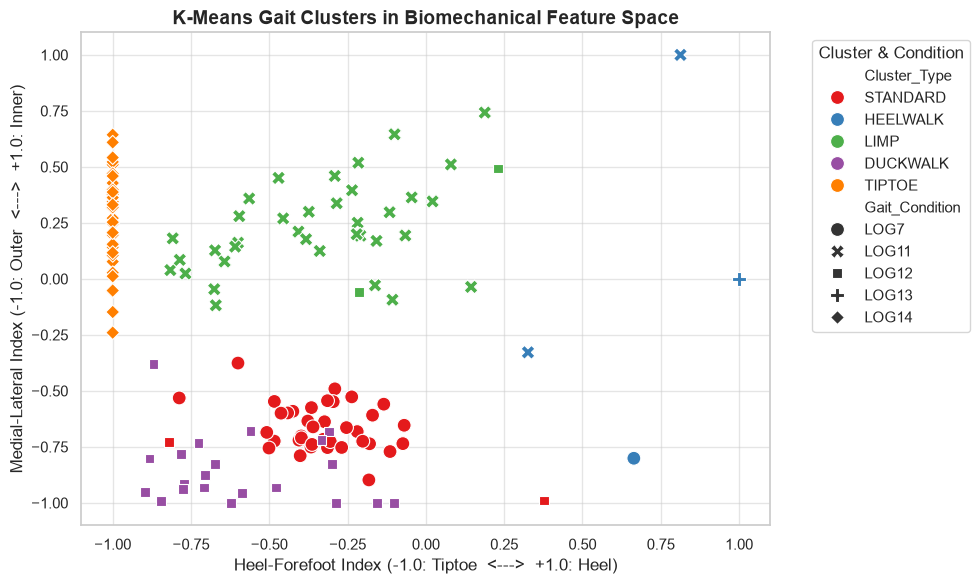

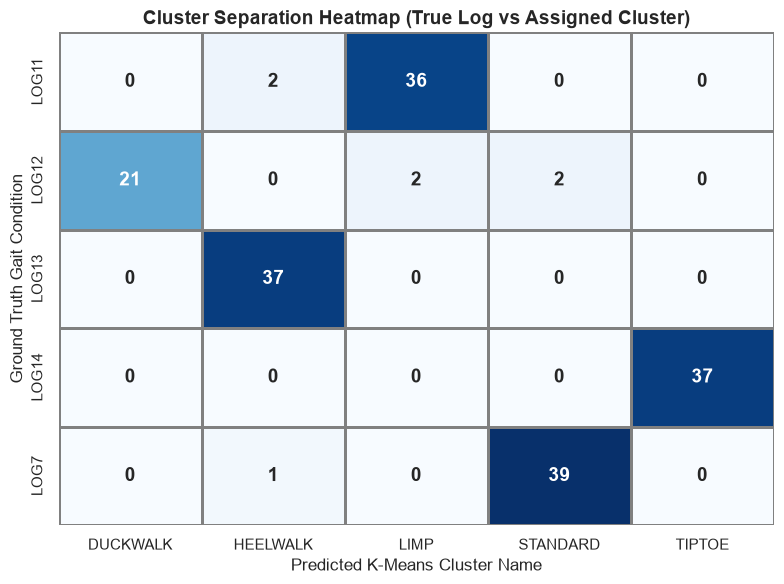

In [95]:
import seaborn as sns

sns.set_theme(style="whitegrid")

named_clusters = [gait_cluster_names[c] for c in predicted_clusters]

# ==========================================
# PLOT 1: 2D Feature Space Scatter Plot
# ==========================================
plt.figure(figsize=(10, 6))

# Combine features and predicted clusters into a plotting DataFrame
# 0 = STANDARD, 1 = HEELWALK, 2 = LIMP, 3 = TIPTOE, 4 = DUCKWALK

plot_df = pd.DataFrame({
    'heel_index': df_clean['heel_index'],
    'medial_index': df_clean['medial_index'],
    'Cluster_Type': named_clusters,
    'Gait_Condition': y
})

sns.scatterplot(
    data=plot_df,
    x='heel_index',
    y='medial_index',
    hue='Cluster_Type',
    style='Gait_Condition',
    s=100,
    palette='Set1'
)

plt.title('K-Means Gait Clusters in Biomechanical Feature Space', fontsize=14, fontweight='bold')
plt.xlabel('Heel-Forefoot Index (-1.0: Tiptoe  <--->  +1.0: Heel)', fontsize=12)
plt.ylabel('Medial-Lateral Index (-1.0: Outer  <--->  +1.0: Inner)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster & Condition")
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: Confusion Matrix Heatmap
# ==========================================
plt.figure(figsize=(8, 6))

# Generate confusion matrix crosstab
conf_matrix = pd.crosstab(results_df['True_Log'], results_df['Cluster_Name'])

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='gray',
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Cluster Separation Heatmap (True Log vs Assigned Cluster)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted K-Means Cluster Name', fontsize=12)  # Updated label
plt.ylabel('Ground Truth Gait Condition', fontsize=12)
plt.tight_layout()
plt.show()

# NOTE that even though LOG13's HEELWALK seems to only be at (1.00,0.00), I believe it's because the data all overlaps on the one spot.

In [96]:
print(kmeans.cluster_centers_)
print(kmeans.labels_)

[[ 1.17059119 -1.08712526 -0.176244   -0.28493399 -0.03779106]
 [-0.48404103  0.3074772   1.65676296  1.68884864 -1.56947409]
 [-1.17034371  0.79576415 -0.17395096 -0.15480596  0.22643448]
 [ 0.67471903  0.88962803 -1.11304272 -1.04780616  1.25788714]
 [-0.43448291 -1.47058223 -0.53579985 -0.53429512  0.43724107]]
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


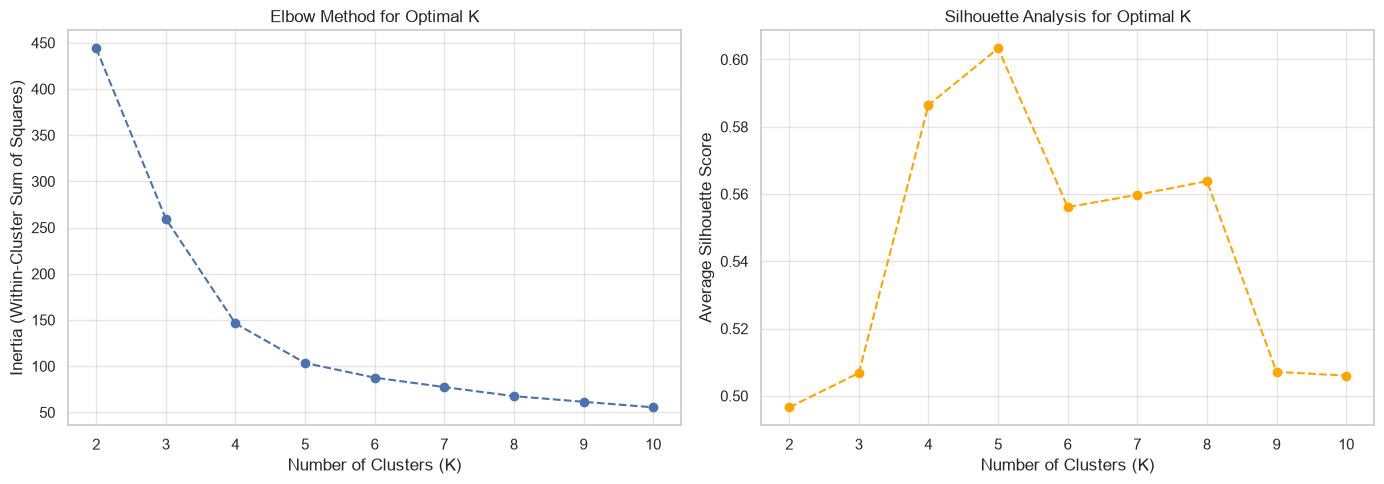


[Analysis Complete] Highest Silhouette Score is at K = 5

--- Cluster Alignment with Data Logs ---
Cluster_Name  DUCKWALK  HEELWALK  LIMP  STANDARD  TIPTOE
True_Log                                                
LOG11                0         2    36         0       0
LOG12               21         0     2         2       0
LOG13                0        37     0         0       0
LOG14                0         0     0         0      37
LOG7                 0         1     0        39       0


In [97]:
from sklearn.metrics import silhouette_score

inertia_values = []
silhouette_avg_scores = []
k_range = range(2, 11)  # Silhouette requires at least 2 clusters

# Calculate metrics for K values from 2 to 10
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_scaled)

    inertia_values.append(km.inertia_)
    silhouette_avg_scores.append(silhouette_score(X_scaled, cluster_labels))

# Plotting the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Elbow Plot
ax1.plot(k_range, inertia_values, marker='o', color='b', linestyle='--')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax1.set_title('Elbow Method for Optimal K')
ax1.grid(True)

# 2. Silhouette Plot
ax2.plot(k_range, silhouette_avg_scores, marker='o', color='orange', linestyle='--')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Average Silhouette Score')
ax2.set_title('Silhouette Analysis for Optimal K')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print the mathematically optimal K based on peak Silhouette score
optimal_k = k_range[np.argmax(silhouette_avg_scores)]
print(f"\n[Analysis Complete] Highest Silhouette Score is at K = {optimal_k}")

# =====================================================================
# RUN FINAL K-MEANS WITH SELECTED K
# =====================================================================
# Update this number based on your visual look at the generated plots
chosen_k = 5

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(X_scaled)

results_df = pd.DataFrame({'True_Log': y, 'Cluster_ID': predicted_clusters})

# Note: If chosen_k != 5, you will need to adjust this naming dictionary mapping!
gait_cluster_names = {
    0: "STANDARD",
    1: "HEELWALK",
    2: "LIMP",
    3: "TIPTOE",
    4: "DUCKWALK"
}
results_df['Cluster_Name'] = results_df['Cluster_ID'].map(gait_cluster_names)

# View cross-tabulation to see how your physical LOG data aligns with clusters
print("\n--- Cluster Alignment with Data Logs ---")
print(pd.crosstab(results_df['True_Log'], results_df['Cluster_Name']))

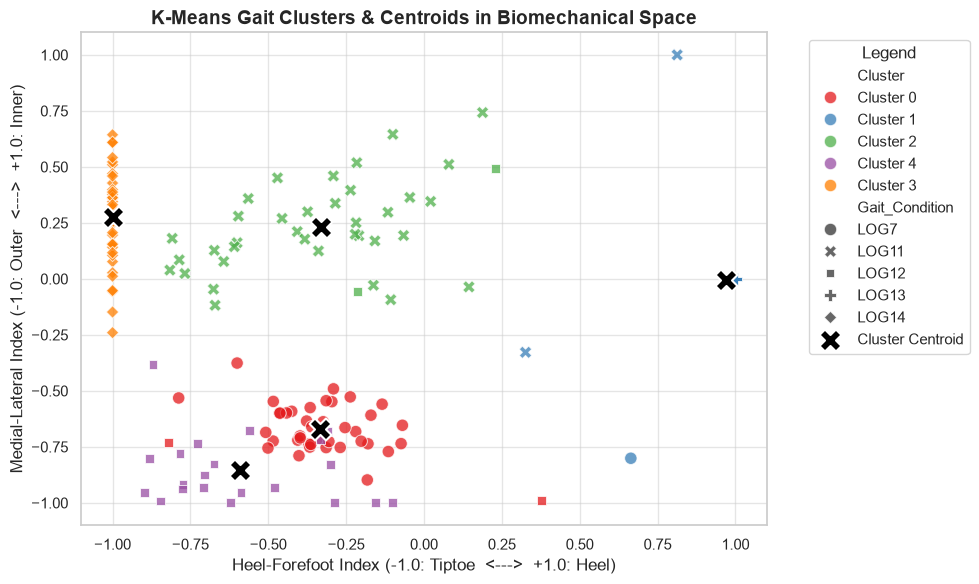

In [98]:
# 1. Un-scale the cluster centers back to physical feature bounds (-1.0 to +1.0)
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)

# Extract center coordinates for the plot axes:
# Column 1 = medial_index (y-axis), Column 2 = heel_index (x-axis)
center_x = centers_unscaled[:, 2]  # heel_index
center_y = centers_unscaled[:, 1]  # medial_index

# 2. Build plot DataFrame
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot_df = pd.DataFrame({
    'heel_index': df_clean['heel_index'],
    'medial_index': df_clean['medial_index'],
    'Cluster': [f"Cluster {c}" for c in predicted_clusters],
    'Gait_Condition': y
})

# 3. Plot individual step observations
sns.scatterplot(
    data=plot_df,
    x='heel_index',
    y='medial_index',
    hue='Cluster',
    style='Gait_Condition',
    s=80,
    palette='Set1',
    alpha=0.75
)

# 4. Overlay Cluster Centroids
plt.scatter(
    center_x,
    center_y,
    c='black',
    s=250,
    marker='X',
    edgecolor='white',
    linewidth=1.5,
    zorder=10,  # Ensures centroids draw on top of all data points
    label='Cluster Centroid'
)

plt.title('K-Means Gait Clusters & Centroids in Biomechanical Space', fontsize=14, fontweight='bold')
plt.xlabel('Heel-Forefoot Index (-1.0: Tiptoe  <--->  +1.0: Heel)', fontsize=12)
plt.ylabel('Medial-Lateral Index (-1.0: Outer  <--->  +1.0: Inner)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Legend")
plt.tight_layout()
plt.show()

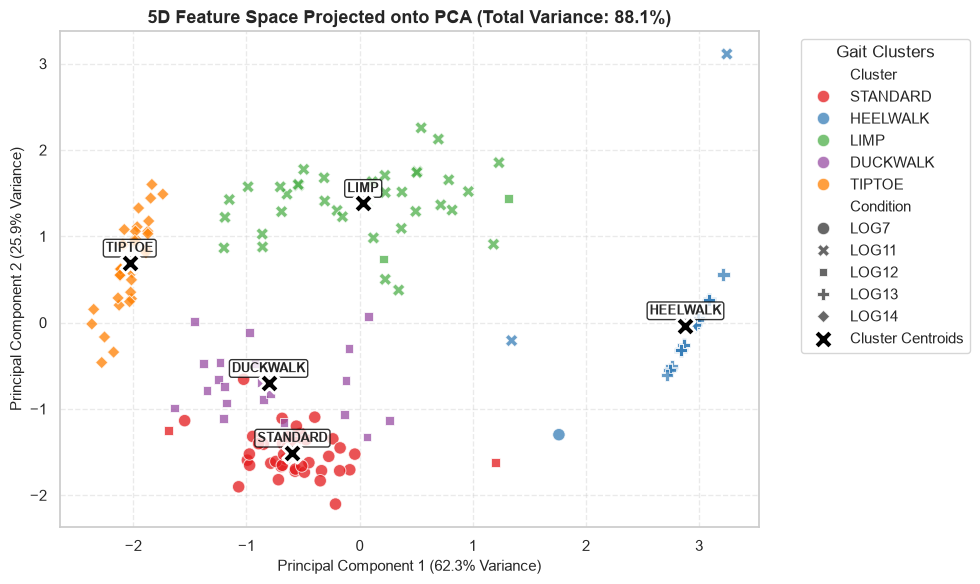

In [99]:
from sklearn.decomposition import PCA

# 1. Fit 2D PCA on the scaled feature matrix
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_ * 100

# 2. Project 5D K-Means cluster centers into 2D PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)

# 3. Build plot DataFrame for individual steps
df_pca = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "Cluster": [gait_cluster_names[c] for c in predicted_clusters],
        "Condition": y,
    }
)

# 4. Render scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot of individual data points
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    style="Condition",
    s=80,
    palette="Set1",
    alpha=0.75,
)

# Overlay Cluster Centroids as prominent 'X' markers
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c="black",
    marker="X",
    s=200,
    linewidths=2,
    edgecolors="white",
    label="Cluster Centroids",
    zorder=10,
)

# Annotate each centroid with its gait cluster name
for idx, (cx, cy) in enumerate(centers_pca):
    plt.annotate(
        gait_cluster_names[idx],
        (cx, cy),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.8
        ),
    )

plt.title(
    f"5D Feature Space Projected onto PCA (Total Variance: {sum(var_exp):.1f}%)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel(f"Principal Component 1 ({var_exp[0]:.1f}% Variance)", fontsize=11)
plt.ylabel(f"Principal Component 2 ({var_exp[1]:.1f}% Variance)", fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Gait Clusters")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

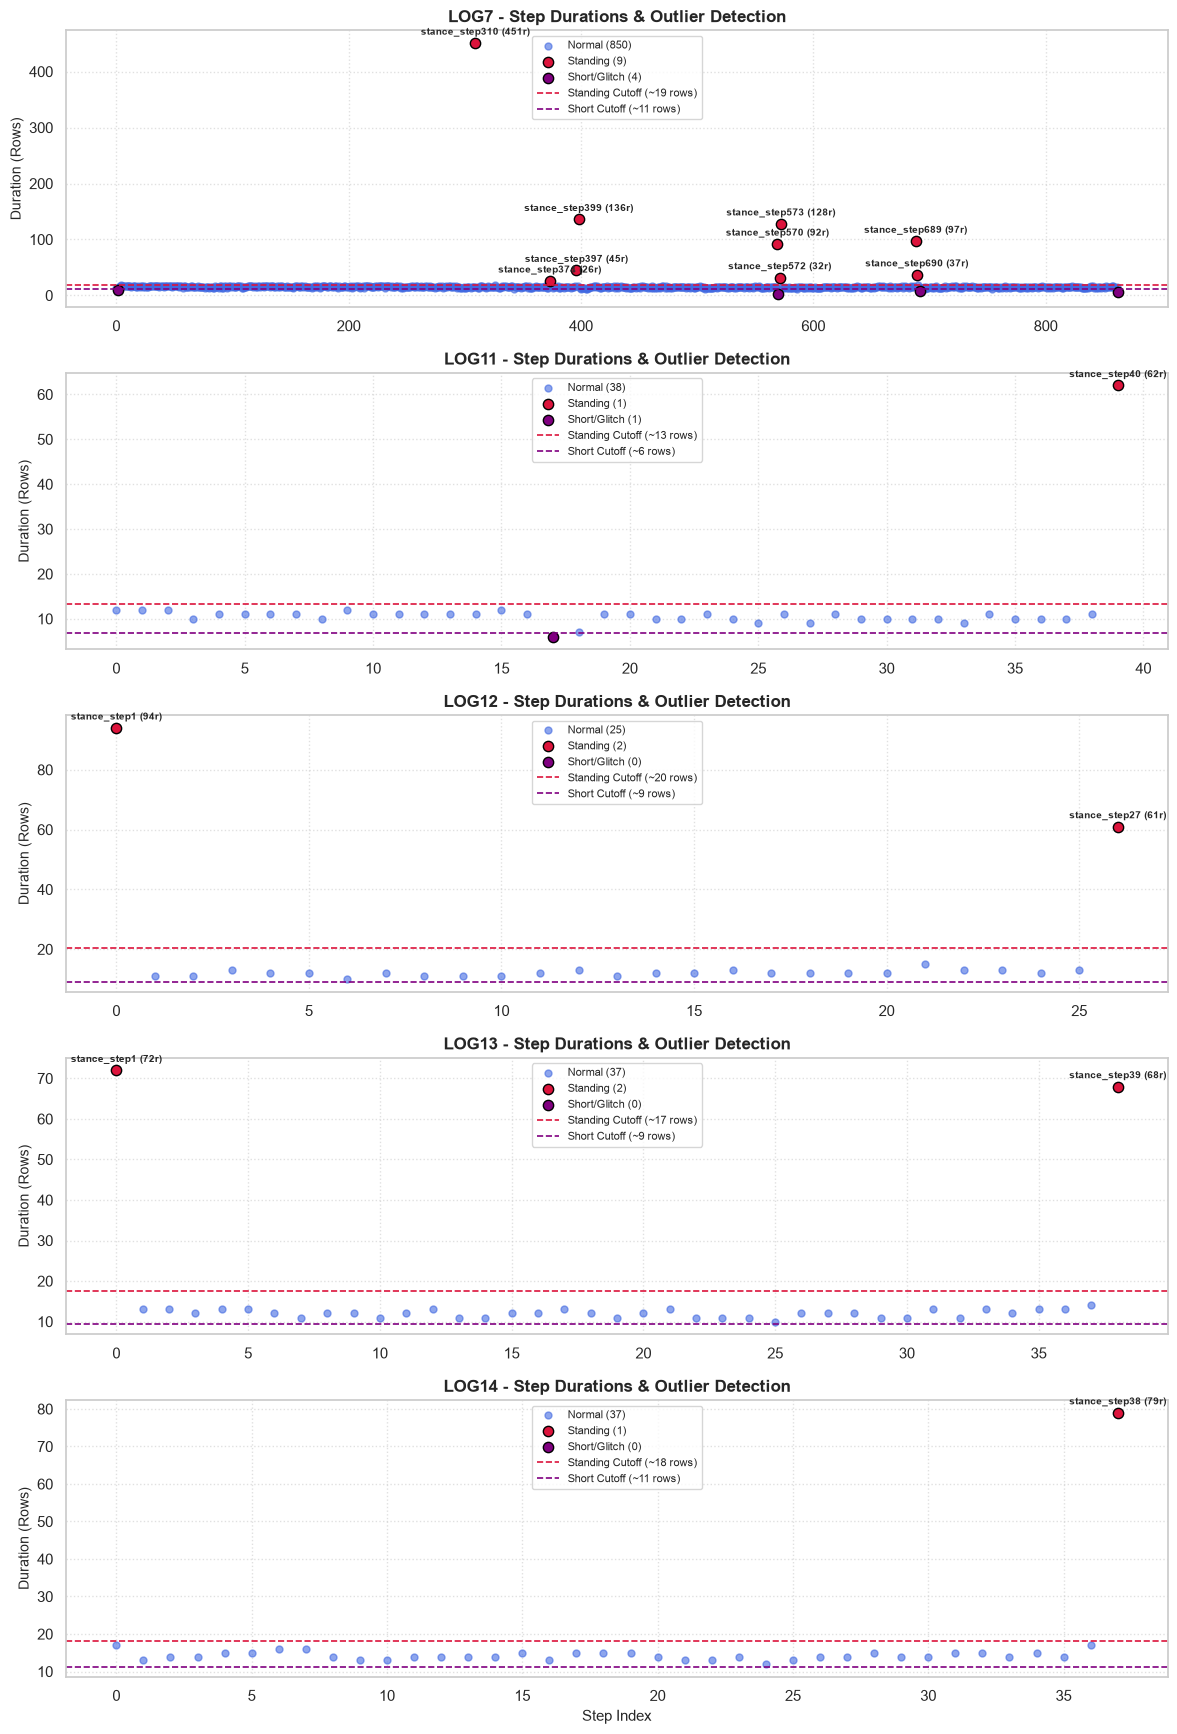

In [101]:
# Create subplots for each log file
fig, axes = plt.subplots(
    len(log_list), 1, figsize=(12, 3.5 * len(log_list)), sharex=False
)

for idx, log_name in enumerate(log_list):
    ax = axes[idx] if len(log_list) > 1 else axes
    stance_dict = raw_stance_dict[log_name]

    if not stance_dict:
        continue

    step_names = np.array(list(stance_dict.keys()))
    row_counts = np.array([arr.shape[0] for arr in stance_dict.values()])
    x_indices = np.arange(len(row_counts))

    # Pass 1: Standing threshold (+0.2 Std Dev)
    mean_raw = np.mean(row_counts)
    std_raw = np.std(row_counts)
    upper_thresh = mean_raw + (0.2 * std_raw)

    # Pass 2: Short step threshold (-2.9 Std Dev on walking baseline)
    walking_baseline = row_counts[row_counts <= upper_thresh]
    if len(walking_baseline) > 0:
        mean_walk = np.mean(walking_baseline)
        std_walk = np.std(walking_baseline)
        lower_thresh = mean_walk - (2.9 * std_walk)
    else:
        lower_thresh = 0

    # Categorize steps into 3 masks
    is_standing = row_counts > upper_thresh
    is_short = row_counts < lower_thresh
    is_normal = ~is_standing & ~is_short

    # Plot normal walking steps
    ax.scatter(
        x_indices[is_normal],
        row_counts[is_normal],
        color="royalblue",
        s=25,
        alpha=0.6,
        label=f"Normal ({sum(is_normal)})",
    )

    # Plot standing still outliers
    ax.scatter(
        x_indices[is_standing],
        row_counts[is_standing],
        color="crimson",
        s=55,
        edgecolors="black",
        label=f"Standing ({sum(is_standing)})",
    )

    # Plot short glitch outliers
    ax.scatter(
        x_indices[is_short],
        row_counts[is_short],
        color="purple",
        s=55,
        edgecolors="black",
        label=f"Short/Glitch ({sum(is_short)})",
    )

    # Draw cutoffs
    ax.axhline(
        y=upper_thresh,
        color="crimson",
        linestyle="--",
        linewidth=1.2,
        label=f"Standing Cutoff (~{int(upper_thresh)} rows)",
    )
    ax.axhline(
        y=lower_thresh,
        color="purple",
        linestyle="--",
        linewidth=1.2,
        label=f"Short Cutoff (~{int(lower_thresh)} rows)",
    )

    # Annotate extreme standing outliers
    for i in np.where(is_standing)[0]:
        ax.annotate(
            f"{step_names[i]} ({row_counts[i]}r)",
            (x_indices[i], row_counts[i]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=7,
            fontweight="bold",
        )

    ax.set_title(
        f"{log_name} - Step Durations & Outlier Detection",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_ylabel("Duration (Rows)", fontsize=10)
    ax.legend(loc="upper center", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.6)

axes[-1].set_xlabel("Step Index", fontsize=11)
plt.tight_layout()
plt.show()

In [102]:
# foot_data[f"{log}"] = dfs[f"df{log}"][['Time_ms', '5th_Metatarsal',
#                 '4th_Metatarsal',
#                 '1st_Metatarsal',
#                 'Heel', 'Medial_Arch',
#                 'Lateral_Arch']]

for log in log_list:
    print(log)
    #print(((foot_data_array[f"{log}"][:, 1:].max())).max())
    print(len(filtered_stance_dict[f"{log}"]))


LOG7
850
LOG11
38
LOG12
25
LOG13
37
LOG14
37
